# Task 1: Exploring and Visualizing the Iris Dataset

**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

**Dataset:** Iris Dataset — a classic multivariate dataset with 150 samples across 3 flower species.

**What I'll do:**
- Load the data with pandas
- Get summary stats
- Create scatter plots, histograms, and box plots


In [1]:
# install any missing libraries (safe to run on colab)
!pip install seaborn matplotlib pandas --quiet

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# use a clean plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

## 1. Load the Dataset

In [3]:
# seaborn has iris built-in, so no download needed
df = sns.load_dataset('iris')

print('shape:', df.shape)          # rows x columns
print('columns:', df.columns.tolist())
print()
df.head()

shape: (150, 5)
columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Summary Statistics

In [4]:
# quick type and null check — important before any analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# descriptive stats: mean, std, min/max, quartiles
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
# how many samples per species?
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## 3. Scatter Plot — Feature Relationships

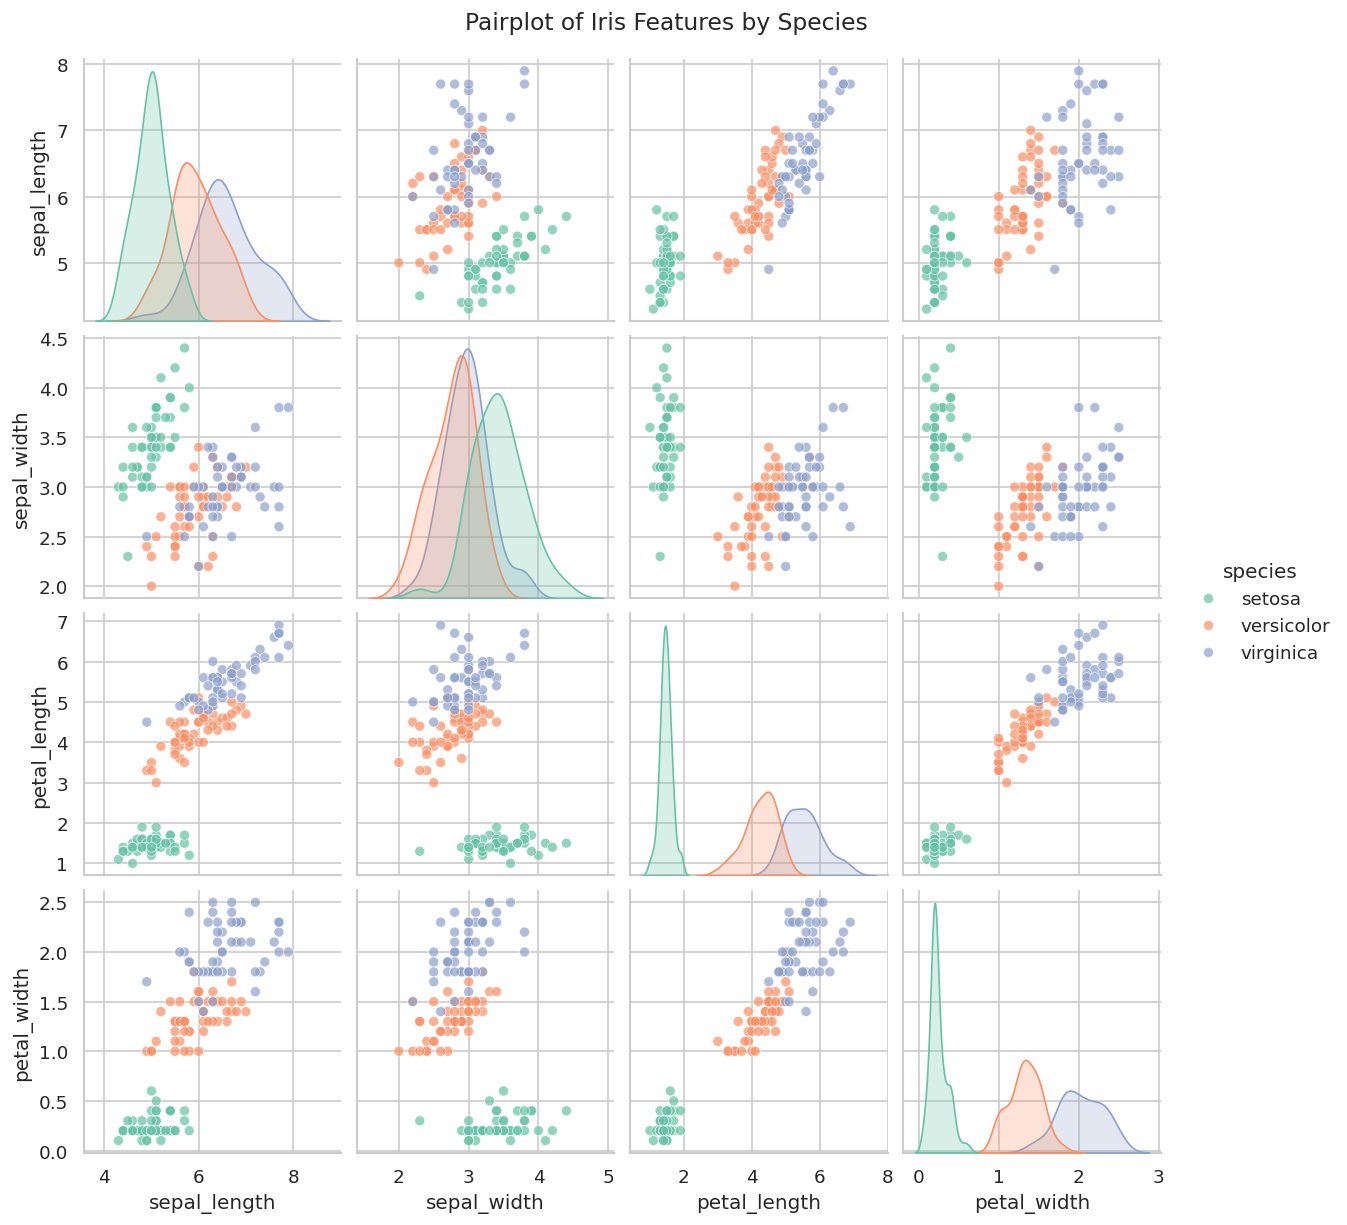

In [7]:
# pairplot shows all feature combinations at once — great for spotting clusters
pair = sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.7})
pair.fig.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=14)
plt.show()

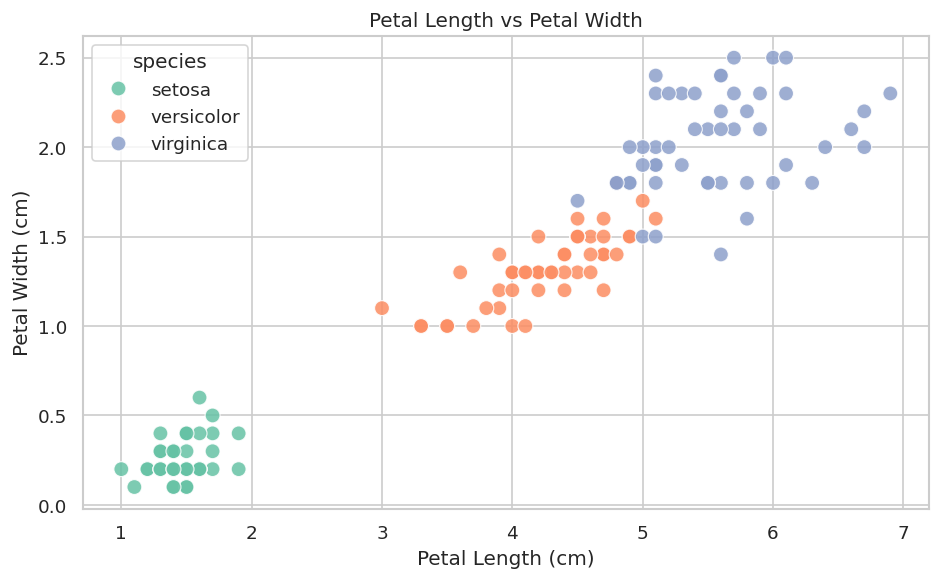

In [8]:
# zooming in on the most separable pair: petal_length vs petal_width
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='petal_length', y='petal_width',
    hue='species', s=80, alpha=0.85
)
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.tight_layout()
plt.show()

## 4. Histograms — Value Distributions

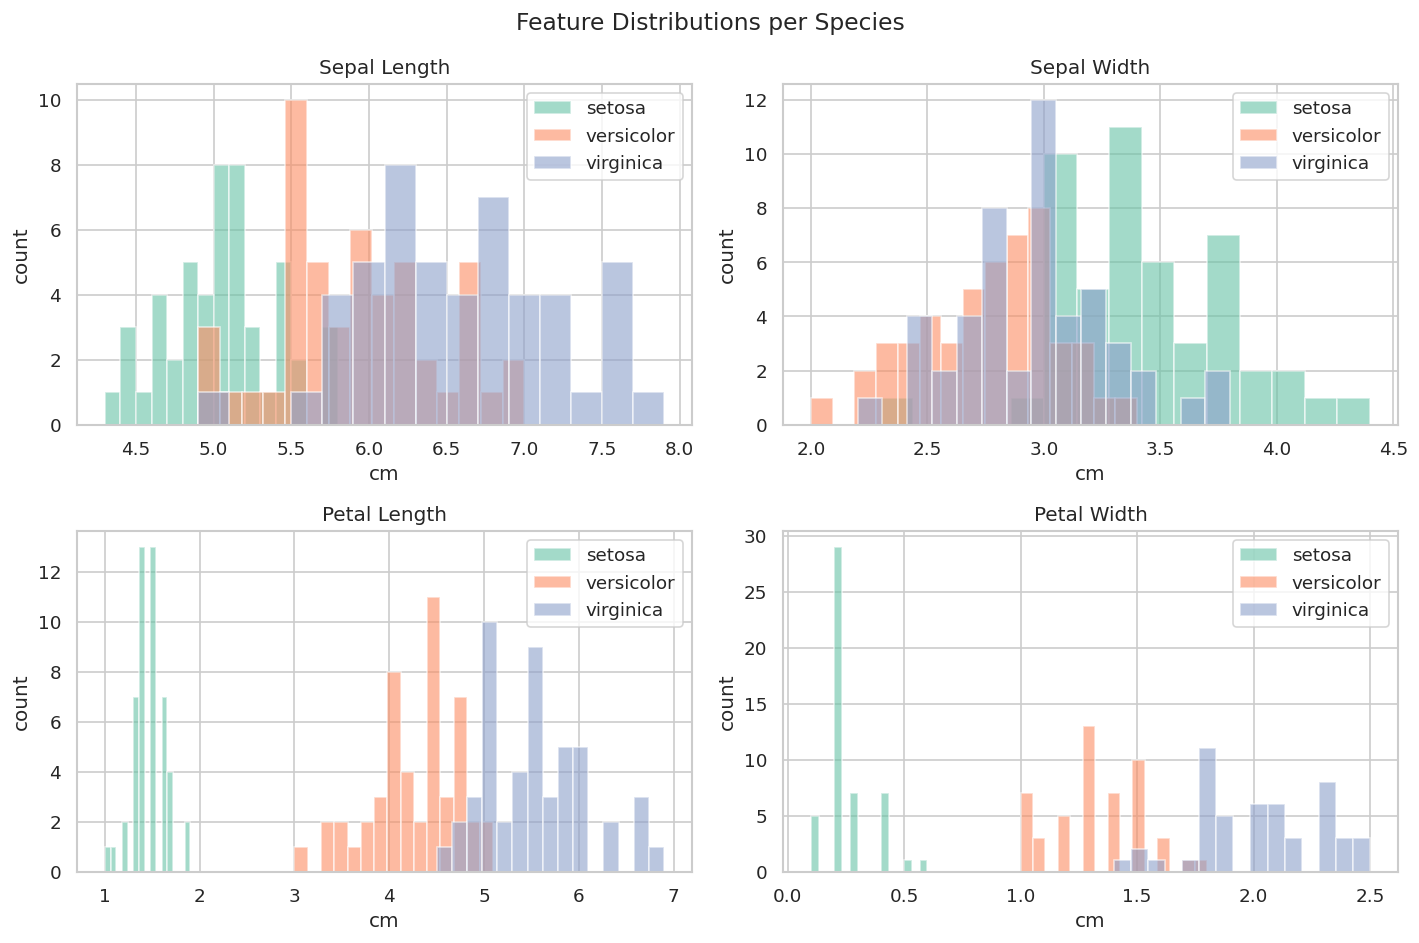

In [9]:
# plot a histogram for each numeric feature, split by species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # easier to index

for i, feature in enumerate(features):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species)
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('cm')
    axes[i].set_ylabel('count')
    axes[i].legend()

fig.suptitle('Feature Distributions per Species', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Box Plots — Spotting Outliers

/tmp/ipykernel_526/764362252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_526/764362252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_526/764362252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_526/764362252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


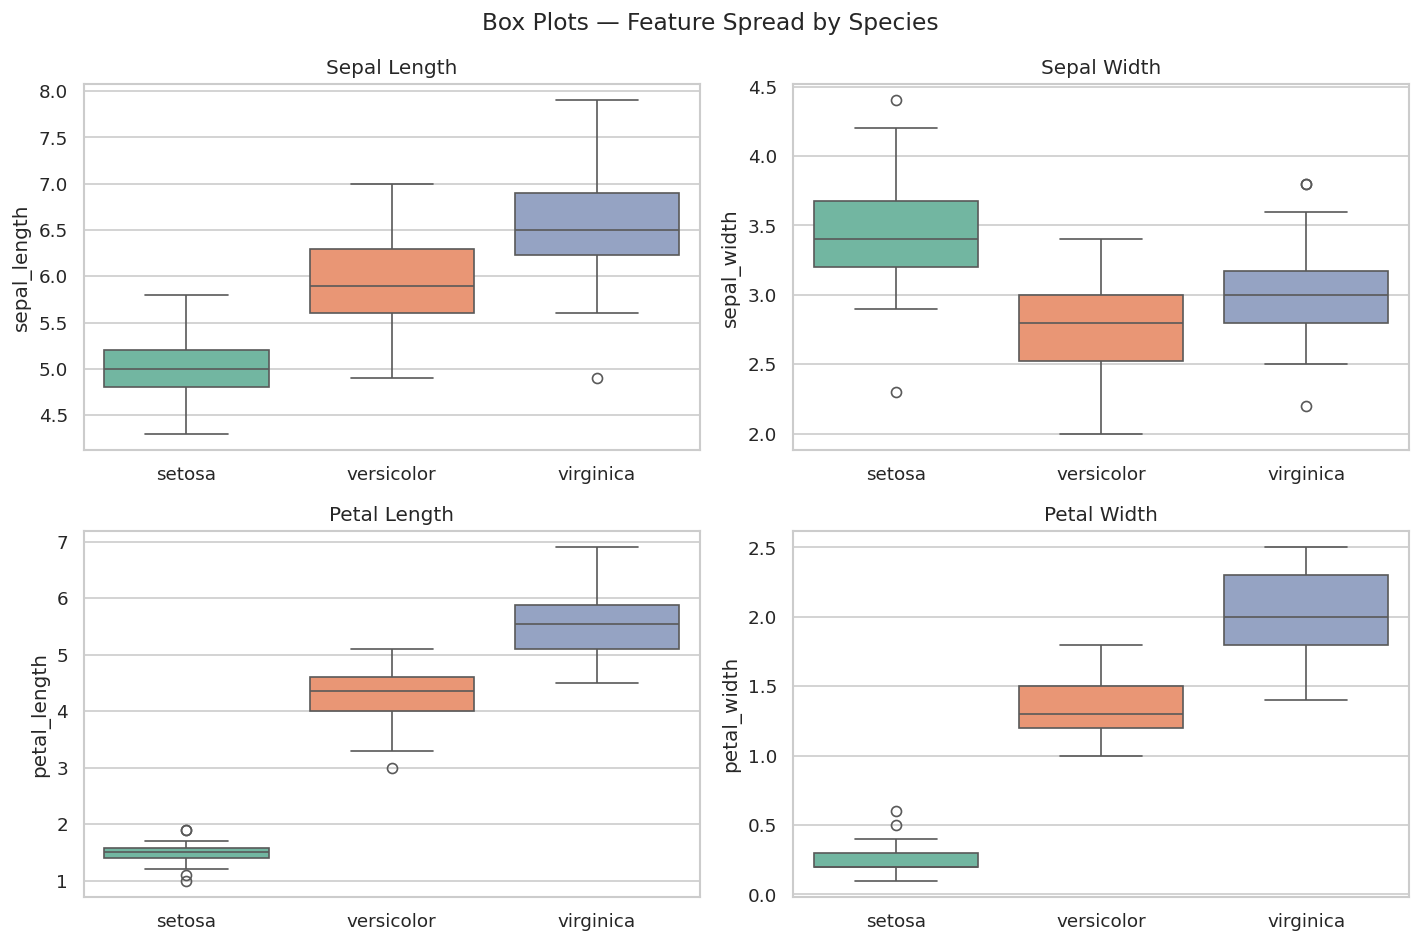

In [10]:
# box plots show median, IQR, and outlier dots all at once
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df, x='species', y=feature,
        ax=axes[i], palette='Set2'
    )
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('')

fig.suptitle('Box Plots — Feature Spread by Species', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

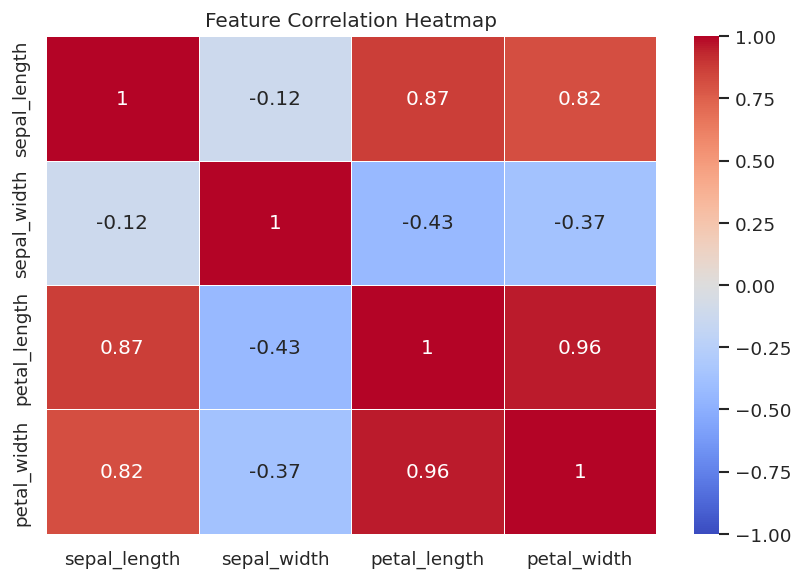

In [11]:
# correlation tells us which features move together
# petal_length and petal_width are strongly correlated (expected)
plt.figure(figsize=(7, 5))
corr = df[features].corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Key Findings

- **Setosa** is clearly separable from the other two species — especially in petal features.
- **Versicolor** and **Virginica** overlap slightly, making them harder to distinguish.
- `petal_length` and `petal_width` are the most informative features (high variance between species).
- `sepal_width` has the most overlap across species and a few mild outliers in setosa.
- Petal length and width are strongly correlated (r ≈ 0.96), so both carry redundant info.

> These insights would directly inform feature selection for any downstream classifier.
